In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

In [15]:
# Load CSV files
df_300 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_300cm.csv', comment='#') 
df_600 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_600cm.csv', comment='#') 
df_900 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_900cm.csv', comment='#')
df_1200 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_1200cm.csv', comment='#')
df_1500 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_1500cm.csv', comment='#')
df_1800 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_1800cm.csv', comment='#')
df_2100 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_2100cm.csv', comment='#')
df_2400 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_2400cm.csv', comment='#')
df_2700 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_2700cm.csv', comment='#')
df_3000 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_3000cm.csv', comment='#')
df_3300 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_3300cm.csv', comment='#')
df_3600 = pd.read_csv('data/espaceSAT/allPositions_wRSSI/FTM_DataTest_EspaceSAT_40MHz_wRSSI_3600cm.csv', comment='#')

In [21]:
# Ensure numeric columns are integers and build the config label
dfs = [df_300, df_600, df_900, df_1200, df_1500,
       df_1800, df_2100, df_2400, df_2700,
       df_3000, df_3300, df_3600]

for df in dfs:
    # coerce non‑numeric values, fill missing, then cast to int
    df['frame_count'] = pd.to_numeric(df['frame_count'], errors='coerce').fillna(0).astype(int)
    df['burst_period'] = pd.to_numeric(df['burst_period'], errors='coerce').fillna(0).astype(int)
    df['config'] = df['frame_count'].astype(str) + ',' + df['burst_period'].astype(str)


In [22]:
df_1500

,physical_distance_cm,frame_count,burst_period,estimated_distance_cm,rtt_ns,rssi_dbm,elapsed_ms,config
0,1500,16,2,2070.0,138.0,-52.0,337.0,"16,2"
1,1500,16,2,2055.0,137.0,-52.0,315.0,"16,2"
2,1500,16,2,2040.0,136.0,-52.0,830.0,"16,2"
3,1500,16,2,2070.0,138.0,-51.0,296.0,"16,2"
4,1500,16,2,2055.0,137.0,-52.0,301.0,"16,2"
...,...,...,...,...,...,...,...,...
5010,1500,24,2,2025.0,135.0,-52.0,1217.0,"24,2"
5011,1500,24,2,2025.0,135.0,-52.0,731.0,"24,2"
5012,1500,24,2,2025.0,135.0,-52.0,1224.0,"24,2"
5013,1500,24,2,2010.0,134.0,-52.0,1261.0,"24,2"


In [23]:
# compute mean + std dev per measurement
def calc_stats(df, true_distance):
    stats = df.groupby('config').agg({
        'estimated_distance_cm': ['count', 'mean', 'median', 'std', 'min', 'max']
    }).round(2)
    stats.columns = ['count', 'mean', 'median', 'std', 'min', 'max']
    stats['error_from_true'] = (stats['median'] - true_distance).round(2)
    stats['abs_error'] = stats['error_from_true'].abs()
    stats = stats.sort_values('abs_error')
    return stats

stats_1800 = calc_stats(df_1800, 1800)
stats_1800

,count,mean,median,std,min,max,error_from_true,abs_error
config,,,,,,,,
"16,2",1000,2388.44,2370.0,67.87,2220.0,3075.0,570.0,570.0
"16,4",1000,2386.94,2370.0,83.46,2085.0,3000.0,570.0,570.0
"16,6",1000,2368.17,2370.0,34.19,2205.0,2715.0,570.0,570.0
"16,8",1000,2429.42,2370.0,136.38,2100.0,3825.0,570.0,570.0
"24,2",1000,2374.38,2370.0,43.51,2145.0,2895.0,570.0,570.0
"0,0",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 1. Map your DataFrames to their respective ground-truth distances
datasets = {
    300: df_300,
    600: df_600,
    900: df_900,
    1200: df_1200,
    1500: df_1500,
    1800: df_1800,
    2100: df_2100,
    2400: df_2400,
    2700: df_2700,
    3000: df_3000,
    3300: df_3300,
    3600: df_3600
}

all_results = []

# 2. Loop through each distance and extract the stats
for dist, df in datasets.items():

    print(dist)
    # Run your existing function
    stats_df = calc_stats(df, dist)
    
    # Reset index to turn 'config' back into a column
    stats_df = stats_df.reset_index()
    
    # Add a column to track which true distance this row belongs to
    stats_df['true_dist_cm'] = dist
    
    # Keep only the specific columns you asked for (plus identifiers)
    subset = stats_df[['true_dist_cm', 'config', 'mean', 'std']]
    all_results.append(subset)

# 3. Combine everything into one master DataFrame
final_summary = pd.concat(all_results, ignore_index=True)

# Optional: Set a multi-index for easy lookup
# This allows you to do: final_summary.loc[150, "10,100"]
final_summary.set_index(['true_dist_cm', 'config'], inplace=True)

#print(final_summary.index.get_level_values('config').unique())

#print(final_summary.xs('16,2', level='config'))
#print(final_summary.xs('16,4', level='config'))
#print(final_summary.xs('16,6', level='config'))
#print(final_summary.xs('16,8', level='config'))
#print(final_summary.xs('24,2', level='config'))

300
600
900
1200
1500
1800
2100
2400
2700
3000
3300
3600
Index(['16,4', '16,8', '16,2', '16,6', '24,2', '0,0'], dtype='str', name='config')
                 mean     std
true_dist_cm                 
300            627.93   30.45
600           2081.34   88.61
900           1606.38   12.41
1200          2128.57  165.38
1500          2053.18   16.46
1800          2388.44   67.87
2100          2751.99   53.79
2400          3644.19  105.14
2700          3206.91   54.89
3000          3450.09   37.17
3300          3943.36   40.27
3600          4265.40  126.78
                 mean    std
true_dist_cm                
300            608.24  36.93
600           2111.34  21.18
900           1605.20   9.50
1200          2203.29  38.83
1500          2089.04  26.87
1800          2386.94  83.46
2100          2929.77  88.73
2400          3709.20  90.72
2700          3229.58  20.40
3000          3478.74  31.60
3300          3932.62  32.74
3600          4272.57  49.05
                 mean     std
true

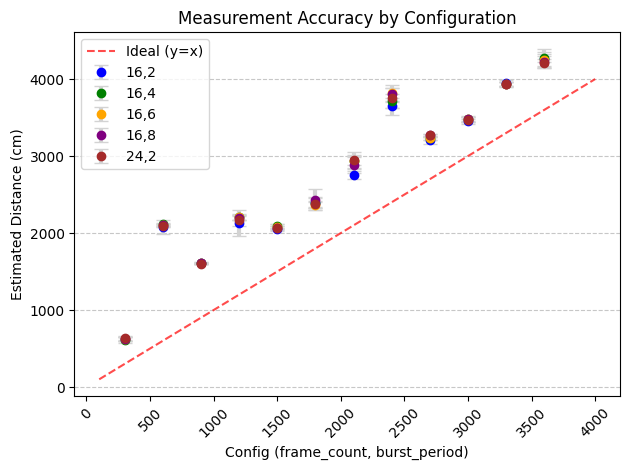

In [31]:
# plot for one config
data_16_2 = final_summary.xs('16,2', level='config')
data_16_4 = final_summary.xs('16,4' , level='config')
data_16_6 = final_summary.xs('16,6' , level='config')
data_16_8 = final_summary.xs('16,8' , level='config')
data_24_2 = final_summary.xs('24,2' , level='config')


plt.errorbar(data_16_2.index, data_16_2['mean'], yerr = data_16_2['std'],fmt='o', color='blue', ecolor='lightgray', elinewidth=3, capsize=5, 
             label='16,2')

plt.errorbar(data_16_4.index, data_16_4['mean'], yerr = data_16_4['std'],fmt='o', color='green', ecolor='lightgray', elinewidth=3, capsize=5, 
             label='16,4')

plt.errorbar(data_16_6.index, data_16_6['mean'], yerr = data_16_6['std'],fmt='o', color='orange', ecolor='lightgray', elinewidth=3, capsize=5, 
             label='16,6')

plt.errorbar(data_16_8.index, data_16_8['mean'], yerr = data_16_8['std'],fmt='o', color='purple', ecolor='lightgray', elinewidth=3, capsize=5, 
             label='16,8')

plt.errorbar(data_24_2.index, data_24_2['mean'], yerr = data_24_2['std'],fmt='o', color='brown', ecolor='lightgray', elinewidth=3, capsize=5, 
             label='24,2')

lims = [100, 4000] 
plt.plot(lims, lims, color='red', linestyle='--', alpha=0.7, label='Ideal (y=x)')

plt.title('Measurement Accuracy by Configuration')
plt.xlabel('Config (frame_count, burst_period)')
plt.ylabel('Estimated Distance (cm)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [33]:
from scipy.optimize import least_squares

def get_linear_fit(data_series):
    # Filter out the 150cm measurement
    # This keeps only rows where the index is NOT 150
    filtered_data = data_series[data_series.index != 150]
    
    x = filtered_data.index.values.astype(float)
    y = filtered_data['mean'].values
    
    # Define residual function: (model_prediction - actual_data)
    def residuals(params, x, y):
        c = params[0]
        m = 1.0
        return (m * x + c) - y
    
    # Initial guess: slope=1, intercept=0
    initial_guess = [0.0]
    
    # Run least_squares
    res = least_squares(residuals, initial_guess, args=(x, y))
    return 1.0, res.x[0]

In [34]:
data.index

Index([300, 600, 900, 1200, 1500, 1800, 2100, 2400, 2700, 3000, 3300, 3600], dtype='int64', name='true_dist_cm')

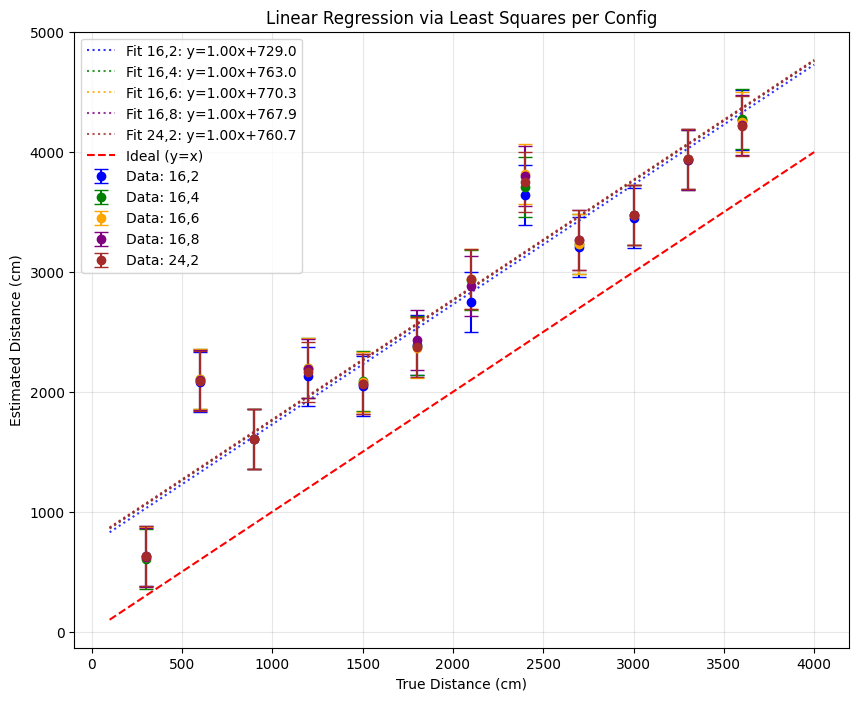

In [35]:
configs = {
    '16,2': (data_16_2, 'blue'), '16,4':  (data_16_4, 'green'), '16,6':  (data_16_6, 'orange'),
        '16,8': (data_16_8, 'purple'), '24,2':  (data_24_2, 'brown')
}

plt.figure(figsize=(10, 8))
x_range = np.array([100, 4000]) # For drawing the fit lines

for label, (df_config, col) in configs.items():
    # 1. Plot the raw error bars
    plt.errorbar(df_config.index, df_config['mean'], yerr=250, 
                 fmt='o', color=col, label=f'Data: {label}', capsize=5)
    
    # 2. Compute Least Squares Fit
    m, c = get_linear_fit(df_config)
    
    # 3. Plot the Fit Line
    plt.plot(x_range, m * x_range + c, color=col, linestyle=':', alpha=0.8,
             label=f'Fit {label}: y={m:.2f}x+{c:.1f}')

# Add Ideal y=x line
plt.plot(x_range, x_range, color='red', linestyle='--', label='Ideal (y=x)')

plt.title('Linear Regression via Least Squares per Config')
plt.xlabel('True Distance (cm)')
plt.ylabel('Estimated Distance (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()